In [257]:
# Import python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [258]:
#1.1 Load data into the python by reading the file and check the head of dataframe

df = pd.read_csv('application.csv')
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,384575,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
1,214010,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
2,142232,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
3,389171,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,283617,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0


In [259]:
#1.2 check shape (rows, columns) and info of the dataframe
print(df.shape)
print(df.info())

(15376, 122)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15376 entries, 0 to 15375
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(63), int64(43), object(16)
memory usage: 14.3+ MB
None


In [260]:
#1.3 Check null values in the dataframe

df.isnull().sum()

SK_ID_CURR                       0
TARGET                           0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     2022
AMT_REQ_CREDIT_BUREAU_WEEK    2022
AMT_REQ_CREDIT_BUREAU_MON     2022
AMT_REQ_CREDIT_BUREAU_QRT     2022
AMT_REQ_CREDIT_BUREAU_YEAR    2022
Length: 122, dtype: int64

In [261]:
#1.4 Check number of unique values in each column

df.nunique()

SK_ID_CURR                    15376
TARGET                            2
NAME_CONTRACT_TYPE                2
CODE_GENDER                       2
FLAG_OWN_CAR                      2
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY         7
AMT_REQ_CREDIT_BUREAU_WEEK        6
AMT_REQ_CREDIT_BUREAU_MON        18
AMT_REQ_CREDIT_BUREAU_QRT         6
AMT_REQ_CREDIT_BUREAU_YEAR       15
Length: 122, dtype: int64

In [262]:
#1.5 Selecting categorical Columns with unique values upto 20

cat_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns
    if df[col].nunique() <= 20]
df[cat_cols].nunique()

NAME_CONTRACT_TYPE             2
CODE_GENDER                    2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               6
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [263]:
#2. For each categorical column compute: Top1, Top2, Top3, Mode, Unique Count.

#Create a function to perform categorical analysis

def categorical_analysis(df):
    #selecting categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    #Create a dataframe with columns: Top1, Top2, Top3, Mode, and Unique Count
    summary = pd.DataFrame(columns=['Top 1', 'Top 2', 'Top 3', 'Mode', 'Unique Count']) 

    for col in cat_cols:
        if df[col].nunique() <= 20:   #using if condition to Select categorical columns with unique values upto 20
            top_values = df[col].value_counts().nlargest(3)
            summary.loc[col, 'Top 1'] = top_values.index[0] if top_values.size > 0 else None
            summary.loc[col, 'Top 2'] = top_values.index[1] if top_values.size > 1 else None
            summary.loc[col, 'Top 3'] = top_values.index[2] if top_values.size > 2 else None
            summary.loc[col, 'Mode'] = df[col].mode()[0] if not df[col].mode().empty else None
            summary.loc[col, 'Unique Count'] = df[col].nunique()
    return summary

categorical_analysis(df)

,Top 1,Top 2,Top 3,Mode,Unique Count
NAME_CONTRACT_TYPE,Cash loans,Revolving loans,None,Cash loans,2
CODE_GENDER,F,M,None,F,2
FLAG_OWN_CAR,N,Y,None,N,2
FLAG_OWN_REALTY,Y,N,None,Y,2
NAME_TYPE_SUITE,Unaccompanied,Family,"Spouse, partner",Unaccompanied,7
NAME_INCOME_TYPE,Working,Commercial associate,Pensioner,Working,6
NAME_EDUCATION_TYPE,Secondary / secondary special,Higher education,Incomplete higher,Secondary / secondary special,5
NAME_FAMILY_STATUS,Married,Single / not married,Civil marriage,Married,6
NAME_HOUSING_TYPE,House / apartment,With parents,Municipal apartment,House / apartment,6
OCCUPATION_TYPE,Laborers,Sales staff,Core staff,Laborers,18


In [264]:
#3. For each numerical column: Calculate 1st quartile (25th percentile), 2nd quartile (50th percentile),
# 3rd quartile (75th percentile), Mean, Median, Skewness, Kurtosis, Standard Deviation, Variance.

from scipy.stats import kurtosis
from scipy.stats import skew

def numerical_analysis(df):
    #selecting numerical columns
    num_cols = df.select_dtypes(include=['number']).columns
    #Create a dataframe with required columns
    summary = pd.DataFrame(columns = ['1st Quartile', '2nd Quartile', '3rd Quartile', 'Mean',
    'Median', 'Skewness', 'Kurtosis', 'Standard Deviation', 'Variance']) 
    for col in num_cols:
        summary.loc[col, '1st Quartile'] = df[col].quantile(0.25)
        summary.loc[col, '2nd Quartile'] = df[col].quantile(0.50)
        summary.loc[col, '3rd Quartile'] = df[col].quantile(0.75)
        summary.loc[col, 'Mean'] = df[col].mean()
        summary.loc[col, 'Median'] = df[col].median()
        summary.loc[col, 'Skewness'] = df[col].skew()
        summary.loc[col, 'Kurtosis'] = df[col].kurtosis()
        summary.loc[col, 'Standard Deviation'] = df[col].std()
        summary.loc[col, 'Variance'] = df[col].var()
    return summary

numerical_analysis(df)

,1st Quartile,2nd Quartile,3rd Quartile,Mean,Median,Skewness,Kurtosis,Standard Deviation,Variance
SK_ID_CURR,190073.5,278047.0,366538.0,277931.605619,278047.0,0.005438,-1.188692,102224.492619,10449846891.277275
TARGET,0.0,0.0,0.0,0.081556,0.0,3.058134,7.353142,0.273695,0.074909
CNT_CHILDREN,0.0,0.0,1.0,0.425989,0.0,1.782952,3.168967,0.731266,0.53475
AMT_INCOME_TOTAL,112500.0,148500.0,202500.0,175875.80018,148500.0,122.122444,15065.730464,947004.372377,896817281302.050293
AMT_CREDIT,270000.0,512997.75,808650.0,598550.179858,512997.75,1.298745,2.410188,402696.324232,162164329550.071411
...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.0,0.0,0.0,0.007863,0.0,32.009802,1554.926875,0.126054,0.01589
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.0,0.0,0.033473,0.0,7.007402,77.228667,0.190786,0.036399
AMT_REQ_CREDIT_BUREAU_MON,0.0,0.0,0.0,0.276996,0.0,7.526564,80.541437,0.944835,0.892713
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.0,0.0,0.258125,0.0,2.655449,7.911261,0.603122,0.363757


In [265]:
#4.1 Probability that a loan application results in default given that applicant is F

total_female_applicants = len(df[df['CODE_GENDER'] == 'F'])
female_applicants_default = len(df[(df['CODE_GENDER'] == 'F') & (df['TARGET'] == 1)])

#P(Default|Female)
P_default_given_female = female_applicants_default/total_female_applicants

#4.2 Probability that a loan application results in default given that applicant is M

#P(Default|Male)
male_applicants = df[df['CODE_GENDER'] == 'M']
P_default_given_male = len(male_applicants[male_applicants['TARGET'] == 1]) / len(male_applicants)

print(f'P(Default | Female): {P_default_given_female: .4f}')
print(f'P(Default | Male): {P_default_given_male: .4f}')

if P_default_given_male > P_default_given_female:
    print("Conclusion: Probability that a loan application results in default given that applicant is Male is more than that of Female.")
else:
    print("Conclusion: Probability that a loan application results in default given that applicant is Female is more than that of Male.")

P(Default | Female):  0.0686
P(Default | Male):  0.1072
Conclusion: Probability that a loan application results in default given that applicant is Male is more than that of Female.


In [266]:
#5.1 Probablity that an applicant is female and the loan application results in default

# P(Female and Default)
total_applicants = len(df)
P_female_and_default = len(df[(df['CODE_GENDER'] == 'F') & (df['TARGET'] == 1)]) / total_applicants

#5.2 Probablity that an applicant is male and the loan application results in default

# P(Male and Default)
P_male_and_default = len(df[(df['CODE_GENDER'] == 'M') & (df['TARGET'] == 1)]) / total_applicants

print(f'P(Female and Dafault): {P_female_and_default: .4f}')
print(f'P(Male and Dafault): {P_male_and_default: .4f}')

P(Female and Dafault):  0.0456
P(Male and Dafault):  0.0360


In [267]:
#6 Calculate the probability that an applicant is a female given the loan application resulted in default.
# Reversing the perspective using Baye's Theorem

#P(Female | Default)
P_female = len(df[df['CODE_GENDER'] == 'F']) / total_applicants
P_default = len(df[df['TARGET'] == 1]) / total_applicants

female_applicants = df[df['CODE_GENDER'] == 'F']
P_default_given_female = len(female_applicants[female_applicants['TARGET'] == 1]) / len(female_applicants)

P_female_given_default = (P_default_given_female * P_female) / P_default
print(f'P(Female | Default): {P_female_given_default: .4f}')

P(Female | Default):  0.5590


In [268]:
#7.1 Stratifiied Sampling based on gender column to represent both genders proportionally

stratified_sample = df.groupby('CODE_GENDER').apply(lambda x:x.sample(min(len(x), 500), random_state=42))

#7.2 Perform descriptive statistics using functions created previously

categorical_summary_stratified = categorical_analysis(stratified_sample)
numerical_summary_stratified = numerical_analysis(stratified_sample)

print("Categorical Summary Straified:")
print(categorical_summary_stratified)
print("\nNumerical Summary Stratified:")
print(numerical_summary_stratified)

#7.3 Conditional Probability of Default

female_applicants_stratified = stratified_sample[stratified_sample['CODE_GENDER'] == 'F']
P_default_given_female_stratified = len(female_applicants_stratified[female_applicants_stratified['TARGET'] == 1]) / len(female_applicants_stratified)

male_applicants_stratified = stratified_sample[stratified_sample['CODE_GENDER'] == 'M']
P_default_give_male_stratified = len(male_applicants_stratified[male_applicants_stratified['TARGET'] == 1]) / len(male_applicants_stratified)

print(f"P(Default | Female): {P_default_given_female_stratified: .4f}")
print(f"P(Default | Male): {P_default_give_male_stratified: .4f}")
print("Conclusion: There is no significant difference between the probabilities calculated for full dataset and the stratified sample.")

C:\Users\anura\AppData\Local\Temp\ipykernel_10748\855382591.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('CODE_GENDER').apply(lambda x:x.sample(min(len(x), 500), random_state=42))


Categorical Summary Straified:
                                                    Top 1  \
NAME_CONTRACT_TYPE                             Cash loans   
CODE_GENDER                                             F   
FLAG_OWN_CAR                                            N   
FLAG_OWN_REALTY                                         Y   
NAME_TYPE_SUITE                             Unaccompanied   
NAME_INCOME_TYPE                                  Working   
NAME_EDUCATION_TYPE         Secondary / secondary special   
NAME_FAMILY_STATUS                                Married   
NAME_HOUSING_TYPE                       House / apartment   
OCCUPATION_TYPE                                  Laborers   
WEEKDAY_APPR_PROCESS_START                         MONDAY   
FONDKAPREMONT_MODE                       reg oper account   
HOUSETYPE_MODE                             block of flats   
WALLSMATERIAL_MODE                           Stone, brick   
EMERGENCYSTATE_MODE                                   

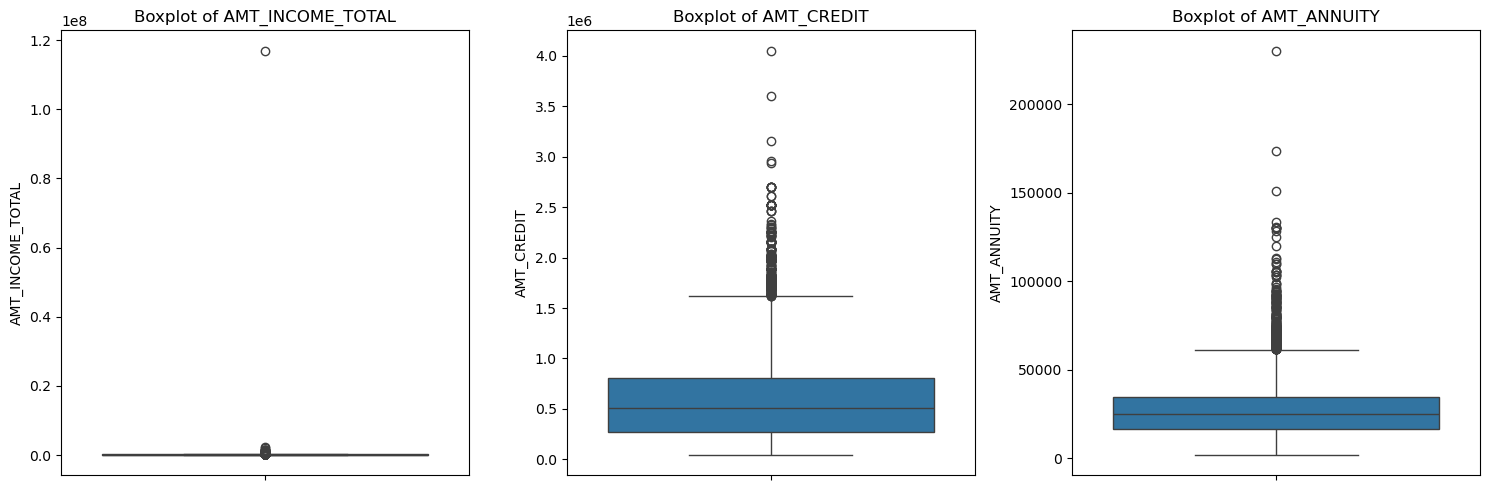

In [269]:
#8.1 Visualize the outliers using boxplot in 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY'.

import seaborn as sns
import matplotlib.pyplot as plt

# Part 1: Visualize Outliers using a function

def visualize_outliers(df, columns):
    plt.figure(figsize=(15, 5))
    for i, column in enumerate(columns, 1):
        plt.subplot(1, len(columns), i)
        sns.boxplot(y=df[column])
        plt.title(f'Boxplot of {column}')
    plt.tight_layout()
    plt.show()
    
# Part 2: Visualize outliers in the specified columns
columns_to_check = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
visualize_outliers(df, columns_to_check)

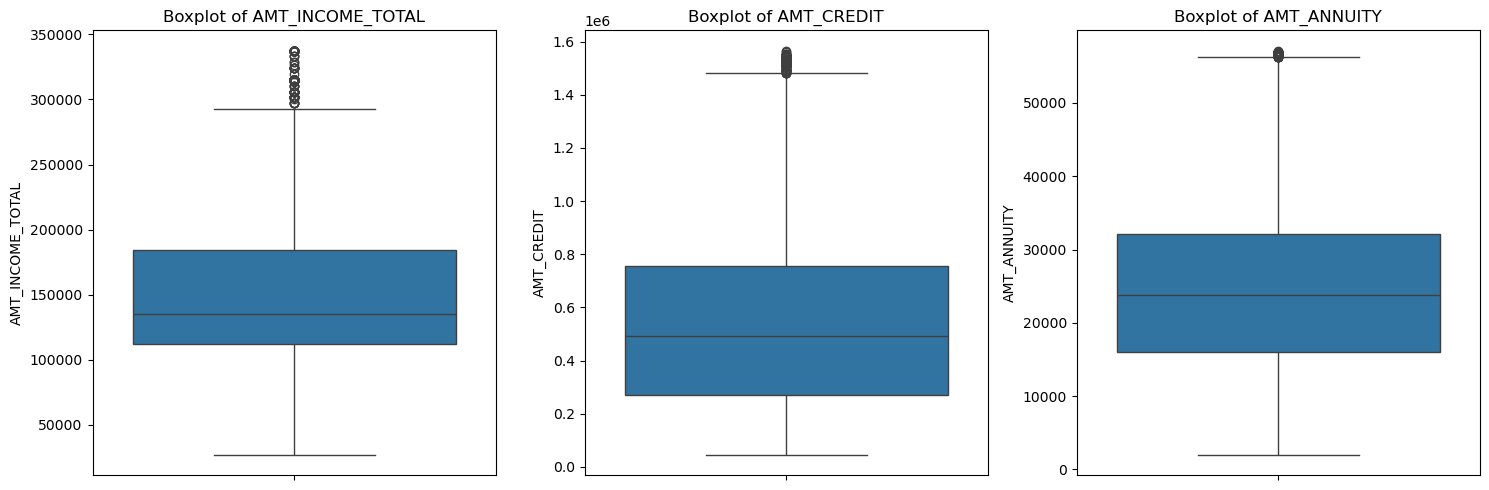

In [270]:
#9.1 Remove Outliers using IQR method

#Create a function to remove the outliers using IQR method
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_fence) & (df[col] <= upper_fence)]
    return df

#Remove outliers in specific columns
columns_to_check = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
df_cleaned = remove_outliers(df, columns_to_check)

#9.2 Visualize outliers in cleaned dataset using function created previously
visualize_outliers(df_cleaned, columns_to_check)

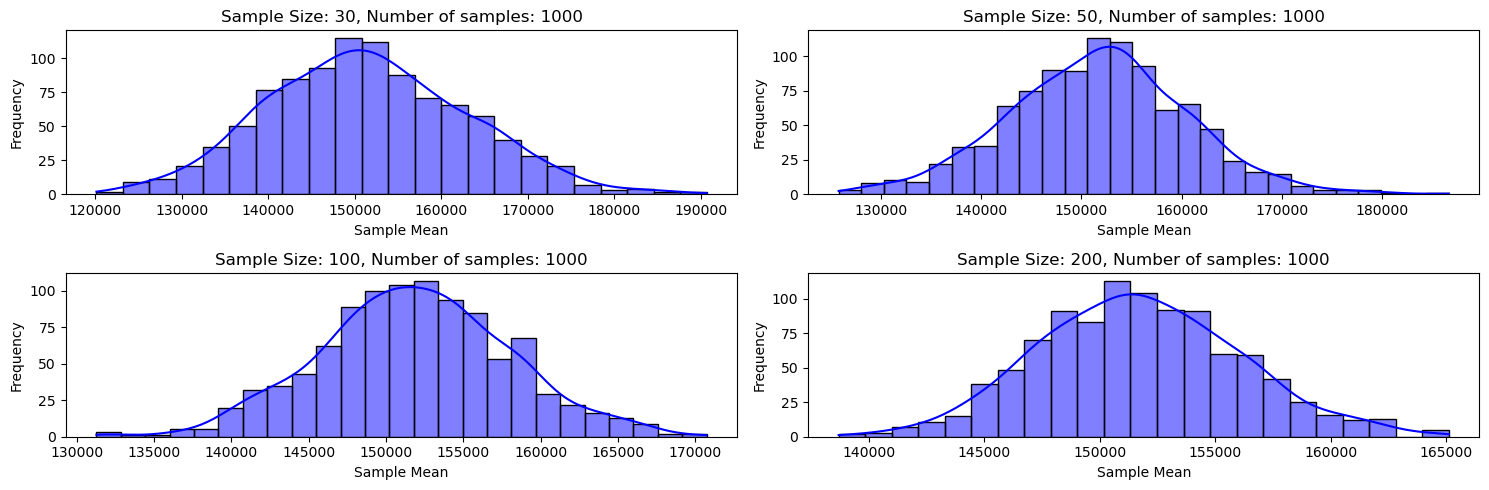

In [271]:
#10  Create a function to evaluate impact of sample size on the distribution of sample means
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_sample_size_impact(df, column, sample_sizes, num_samples=1000):
    plt.figure(figsize=(15, 5))
    for i, size in enumerate(sample_sizes, 1):
        sample_means = [df_cleaned[column].sample(size, replace=True).mean() for _ in range(num_samples)]
        plt.subplot(2, 2, i)
        sns.histplot(sample_means, kde=True, color='b')
        plt.title(f'Sample Size: {size}, Number of samples: {num_samples}')
        plt.xlabel('Sample Mean')
        plt.ylabel('Frequency')
        
    plt.tight_layout()
    plt.show()

sample_sizes = [30, 50, 100, 200]
evaluate_sample_size_impact(df_cleaned, 'AMT_INCOME_TOTAL', sample_sizes)

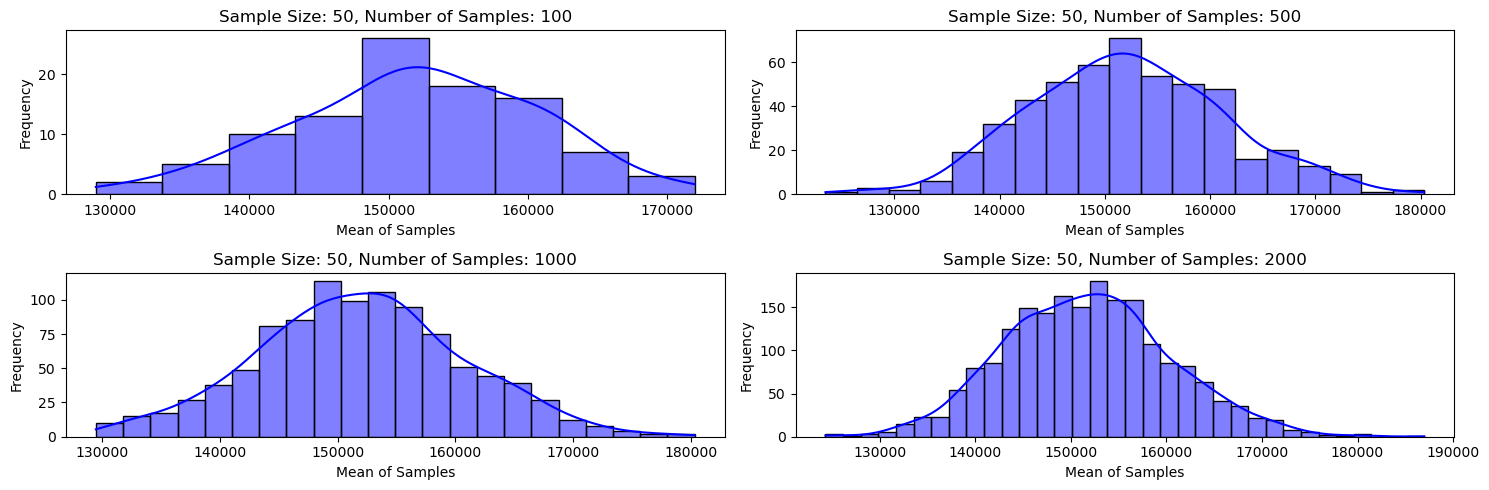

In [272]:
#11 Create a function to evaluate the impact of number of samples on distribution of sample means with a fixed sample size.

def evaluate_number_of_samples_impact(df, column, sample_size, num_samples):
    plt.figure(figsize=(15, 5))
    for i, sample in enumerate(num_samples, 1):
        sample_means = [df[column].sample(sample_size, replace=True).mean() for _ in range(sample)]
        plt.subplot(2, 2, i)
        sns.histplot(sample_means, kde=True, color='b')
        plt.title(f'Sample Size: {sample_size}, Number of Samples: {sample}')
        plt.xlabel('Mean of Samples')
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

num_samples = [100, 500, 1000, 2000]
evaluate_number_of_samples_impact(df_cleaned, 'AMT_INCOME_TOTAL', 50, num_samples)

#12. Conduct a one-sample t-test to find if the average total income of loan applicants is significantly different from 
a hypothesized population mean of $160,000?

In [273]:
# One sample t-test on AMT_INCOME_TOTAL

from scipy.stats import ttest_1samp

#Hypothesized population mean 
population_mean = 160000

# Perform one sample t-test on AMT_INCOME_TOTAL
t_stat, p_value = ttest_1samp(df_cleaned['AMT_INCOME_TOTAL'], population_mean)

print(f'One Sample t-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}')

if p_value < 0.05:
    print("Reject Null Hypothesis: The average AMT_INCOME_TOTAL is significantly different from $160,000.")
else:
    print("Fail to reject the Null Hypothesis: No significant difference from the hypothesized mean of $160,000.")

One Sample t-test: t-statistic = -15.4307, p-value = 0.0000
Reject Null Hypothesis: The average AMT_INCOME_TOTAL is significantly different from $160,000.


#13. Find the 95% Confidence Intervals for the mean Credit Amount for all loan applicants.

In [274]:
# Finding 95% CI for mean AMT_CREDIT for all loan applicants

#importing python library (norm) to calculate z-score
import numpy as np
from scipy.stats import norm


def calculate_CI(data, confidence_level=0.95):
    sm = np.mean(data)   #sample mean
    std = np.std(data, ddof=1)  #standard deviation
    n = len(data)  # number of samples
    se = std/np.sqrt(n)   # standard error
    zscore = norm.ppf(1 - (1 - confidence_level)/2)
    lower = sm - zscore * se  #lower interval
    upper = sm + zscore * se  #upper interval
    return lower, upper

data = df_cleaned['AMT_CREDIT']
calculate_CI(data, confidence_level=0.95)

(np.float64(541081.0178764695), np.float64(552192.3479046144))

In [275]:
# Another method to find the CI is as follows:

import numpy as np
import scipy.stats as stats

#Calcualte the mean and standard error of AMT_CREDIT
mean_amt_credit = np.mean(df_cleaned['AMT_CREDIT'])
SE_amt_credit = stats.sem(df_cleaned['AMT_CREDIT'])

#Calculate the 95% confidence interval 
confidence_interval = stats.t.interval(0.95, len(df_cleaned['AMT_CREDIT']) - 1, loc = mean_amt_credit, scale = SE_amt_credit)
print(f'95% Confidence Interval for AMT_CREDIT: {confidence_interval}')

95% Confidence Interval for AMT_CREDIT: (np.float64(541080.5414029157), np.float64(552192.8243781682))


#14. Is there a significant difference in AMT_ANNUITY across different types of contracts?

In [276]:
import numpy as np
import scipy.stats as stats

# Null Hypothesis: There is no significant different in AMT_ANNUITY for both types of contracts.
# Alternative Hypothesis: AMT_ANNUITY differs significantly between both types of contracts.

# Applying ANOVA for Bivariate Analysis 
# Group by the target variable NAME_CONTRACT_TYPE(Cash loans, Revolving loans)

amt_annuity_for_cash_loans = df_cleaned[df_cleaned['NAME_CONTRACT_TYPE'] == 'Cash loans']['AMT_ANNUITY']
amt_annuity_for_revolving_loans = df_cleaned[df_cleaned['NAME_CONTRACT_TYPE'] == 'Revolving loans']['AMT_ANNUITY']

# Perform the ANOVA test
from scipy.stats import f_oneway

#perform anova on the two groups
f_stat, p_value = f_oneway(amt_annuity_for_cash_loans, amt_annuity_for_revolving_loans)
print(f_stat, p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference in AMT_ANNUITY across contract types.")
else:
    print("Fail to reject Null Hypothesis: No significant difference in AMT_ANNUITY across contract types.")

1430.188449259134 3.3960377845595936e-298
Reject Null Hypothesis: Significant difference in AMT_ANNUITY across contract types.


#15. Is there an association between CODE_GENDER and loan default?

In [277]:
# Perform Chi-Square test

# Null Hypothesis: There is no association between CODE_GENDER and loan default (TARGET).
# Alternative Hypothesis: There is a significant association between CODE_GENDER and loan default (TARGET).

# Create a contingency table of count of loan default by CODE_GENDER

contingency_table = pd.crosstab(df_cleaned['CODE_GENDER'], df_cleaned['TARGET'])

#Perform the chi-square test of independence by importing python library

from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi2-Stat: {chi2_stat:.4f}, P-value: {p_value:.4f}')

if p_value < 0.05:
    print("Reject the Null Hypothesis: There is an association between gender and loan default.")
else:
    print("Fail to reject Null Hypothesis: No significant association between gender and loan default.")

Chi2-Stat: 66.2666, P-value: 0.0000
Reject the Null Hypothesis: There is an association between gender and loan default.


#16. To find which of these categorical variables are not significantly associated with loan default.

In [278]:
# We can create a function to perform chi-sqaure test if independence

def chi2_test(df, columns_list, column):
    for col in columns_list:
        CT = pd.crosstab(df[col], df[column])
        chi2_stat, p_value, dof, expected = chi2_contingency(CT)
        print(f'Chi2-Stat: {chi2_stat:.4f}, P-value: {p_value:.4f}')
        if p_value < 0.05:
            print(f"Reject the Null Hypothesis: There is an association between {col} and loan default.")
        else:
            print(f"Fail to reject Null Hypothesis: No significant association between {col} and loan default.")

columns_list = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE']
chi2_test(df_cleaned, columns_list, 'TARGET')

Chi2-Stat: 66.2666, P-value: 0.0000
Reject the Null Hypothesis: There is an association between CODE_GENDER and loan default.
Chi2-Stat: 1.3637, P-value: 0.2429
Fail to reject Null Hypothesis: No significant association between FLAG_OWN_CAR and loan default.
Chi2-Stat: 0.6557, P-value: 0.4181
Fail to reject Null Hypothesis: No significant association between FLAG_OWN_REALTY and loan default.
Chi2-Stat: 11.1300, P-value: 0.0008
Reject the Null Hypothesis: There is an association between NAME_CONTRACT_TYPE and loan default.


#17. Is the average loan amount for female applicants within the 95% Confidence Interval 
of the overall average loan amount for all applicants?

In [279]:
from scipy.stats import stats

mean_amt_credit = np.mean(df_cleaned['AMT_CREDIT'])  #average loan amount
se_amt_credit = stats.sem(df_cleaned['AMT_CREDIT'])  #standard error loan amount

CI = stats.t.interval(0.95, len(df_cleaned['AMT_CREDIT']) - 1, loc = mean_amt_credit, scale = se_amt_credit)
avg_loan_amt_for_F = df_cleaned[df_cleaned['CODE_GENDER'] == 'F']['AMT_CREDIT'].mean()

print(f'Confidence Interval: {CI:.2f}, Avg Loan Amount for Females: {avg_loan_amt_for_F:.2f}')
if CI[0] <= avg_loan_amt_for_F <= CI[1]:
    print("Average loan amount for female applicants is within 95% CI of the overall average loan amount of all applicants")
else:
    print("Average loan amount for female applicants is not within 95% CI of the overall average loan amount of all applicants")

C:\Users\anura\AppData\Local\Temp\ipykernel_10748\844702104.py:4: DeprecationWarning: Please import `sem` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  se_amt_credit = stats.sem(df_cleaned['AMT_CREDIT'])  #standard error loan amount


AttributeError: `scipy.stats.stats` has no attribute `t`; furthermore, `scipy.stats.stats` is deprecated and will be removed in SciPy 2.0.0.

#18. Does the 95% CI for the mean income of applicants who own a car overlap with those who do not?

In [ ]:
#Create two sepate groups based on car ownership
car_owners = df_cleaned[df_cleaned['FLAG_OWN_CAR'] == 'Y']['AMT_INCOME_TOTAL']
non_car_owners = df_cleaned[df_cleaned['FLAG_OWN_CAR'] == 'N']['AMT_INCOME_TOTAL']

#Calculate mean of total income for both groups
mean_car_owners = car_owners.mean()
mean_non_car_owners = non_car_owners.mean()

#Calculate Standard Error for both groups
se_car_owners = stats.sem(car_owners)  
se_non_car_owners = stats.sem(non_car_owners) 

#Calculate the 95% Confidence Intervals for both groups (Confidence level = 0.95)
CI_car_owners = stats.t.interval(0.95, len(car_owners) - 1, loc = mean_car_owners, scale = se_car_owners)
CI_non_car_owners = stats.t.interval(0.95, len(non_car_owners) - 1, loc = mean_non_car_owners, scale = se_non_car_owners)

print(CI_car_owners)
print(CI_non_car_owners)
print("Since the confidence intervals do not overlap, we can conclusively say that the mean income for 
applicants who own a car is significantly different from those who do not based solely on these intervals.")

#19. Conduct a one-sample t-test to evaluate if the mean annuity amount is $30,000 based on industry standards.

In [ ]:
from scipy.stats import ttest_1samp

# State the hypothesis
# Null Hypothesis: No significant difference between mean annuity amount and hypothesized mean of $30,000.
# Alternate Hypothesis: The average annuity amount is significantly different from hypothesized mean of $30,000.

#Hypothesized mean for AMT_ANNUITY
hypothesized_mean = 30000

t_stat, p_value = ttest_1samp(df_cleaned['AMT_ANNUITY'], hypothesized_mean)

print(f"One-sample T-test for AMT_ANNUITY: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Reject Null Hypothesis: The average annuity amount is significantly different from the hypothesized mean of $30,000.")
else:
    print("Fail to reject Null Hypothesis: No significant difference between mean annuity amount and hypothesized mean of $30,000.")

#20 Assume that the minimum income threshold is $180,000 for a specific loan program.
Determine whether the average income of applicants significantly differs from this threshold.

In [ ]:
from scipy.stats import ttest_1samp
import numpy as np

#Hypothesized population mean
threshold_income = 180000

t_stat, p_value = ttest_1samp(df_cleaned['AMT_INCOME_TOTAL'], threshold_income)
print(f"One-sample t-test for AMT_INCOME_TOTAL: t-stat = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Reject Null Hypothesis: Mean total income is significantly different from the minimum income threshold of $180,000.")
else:
    print("Fail to reject Null Hypothesis: No significant difference between mean total income and threshold of $180,000.")